<a href="https://colab.research.google.com/github/SoniaCamila13/Clasificacion_correos_BERT_USFQ/blob/main/03_entrenamiento_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Carga del dataset anonimizado:

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd


Saving correos_para_training.csv to correos_para_training.csv


Columnas: Asunto, Cuerpo y Etiqueta (La Columna "Remitente" se elima porque no es relevante para el modelo y por protección datos personales)

In [ ]:
df = pd.read_csv("correos_para_training.csv", sep=';')
df.head()

,Asunto,Cuerpo,Etiqueta
0,<NOMBRE>,"Ya cancele el valor de mi reingreso, que debo ...",Otros trámites
1,<NOMBRE>,Cómo está? Una pregunta cómo puedo convalidar ...,Otros trámites
2,Transcript,"Neccesito mi transcript, <CEDULA>, <NOMBRE>, b...",Certificados
3,Paso de matrícula,"Buen día, adjunto la carta para hacer un paso ...",Otros trámites
4,Paso de matrícula,"Buen día, adjunto la carta para hacer un paso ...",Otros trámites


Preprocesamiento: Concatenar columnas "Asunto" y "Contenido" limpieza del contenido

In [ ]:
import re

# unir texto
df["texto"] = df["Asunto"].fillna("") + " " + df["Cuerpo"].fillna("")

# funciones
def remove_disclaimers(text):
    patterns = [
        r"este mensaje.*", r"este correo.*",
        r"aviso de confidencialidad.*",
        r"confidencialidad.*",
        r"this message.*", r"this email.*",
        r"confidential.*"
    ]
    for p in patterns:
        text = re.sub(p, "", str(text), flags=re.IGNORECASE | re.DOTALL)
    return text

def remove_threads(text):
    patterns = [r"de:.*", r"from:.*", r"enviado:.*", r"sent:.*"]
    for p in patterns:
        text = re.sub(p, "", str(text), flags=re.IGNORECASE | re.DOTALL)
    return text

def clean_text(text):
    text = re.sub(r'\S+@\S+', '', str(text))
    text = re.sub(r'http\S+|www.\S+', '', text)
    text = re.sub(r'[^a-zA-ZáéíóúÁÉÍÓÚñÑ0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# aplicar
df["texto"] = df["texto"].apply(remove_disclaimers)
df["texto"] = df["texto"].apply(remove_threads)
df["texto_limpio"] = df["texto"].apply(clean_text)

SKLEARN: etiquetas

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label"] = le.fit_transform(df["Etiqueta"])

print(df["label"].value_counts())

label
0    11052
1     7200
3     5342
2     1867
Name: count, dtype: int64


In [ ]:
print(df["Etiqueta"].value_counts())

Etiqueta
Certificados                     11052
Otros trámites                    7200
Registro y retiro de materias     5342
Proceso de Graduación             1867
Name: count, dtype: int64


División de Dataset en TRAIN / TEST

In [ ]:
from datasets import Dataset

dataset = Dataset.from_pandas(df[["texto_limpio", "label"]])

dataset = dataset.train_test_split(test_size=0.2, seed=42)

dataset

DatasetDict({
    train: Dataset({
        features: ['texto_limpio', 'label'],
        num_rows: 20368
    })
    test: Dataset({
        features: ['texto_limpio', 'label'],
        num_rows: 5093
    })
})

Tokenización con BERT:

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")

def tokenize(batch):
    return tokenizer(batch["texto_limpio"], padding=True, truncation=True)

dataset = dataset.map(tokenize, batched=True)

dataset = dataset.rename_column("label", "labels")
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Map:   0%|          | 0/20368 [00:00<?, ? examples/s]

Map:   0%|          | 0/5093 [00:00<?, ? examples/s]

Métricas:

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    logits, labels = pred
    preds = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted'
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

Modelo con la configuración ganadora:

In [ ]:
from transformers import BertForSequenceClassification, TrainingArguments

model = BertForSequenceClassification.from_pretrained(
    "dccuchile/bert-base-spanish-wwm-cased",
    num_labels=len(df["label"].unique())
)

training_args = TrainingArguments(
    output_dir="./modelo_final_25k",
    learning_rate=2e-5,   # 🔥 GANADOR
    num_train_epochs=3,   # 🔥 GANADOR
    per_device_train_batch_size=8
)

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

Trainer:

Se utilizó un data collator para manejar dinámicamente el padding de las secuencias y asegurar consistencia en los batches durante el entrenamiento.

In [ ]:
from transformers import Trainer, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

Entrenamiento:

In [ ]:
trainer.train()

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Step,Training Loss
500,0.561381
1000,0.355423
1500,0.321140
2000,0.278365
2500,0.280397
3000,0.209351
3500,0.190577
4000,0.182398
4500,0.176466
5000,0.171861


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=7638, training_loss=0.21158740357536082, metrics={'train_runtime': 2305.2061, 'train_samples_per_second': 26.507, 'train_steps_per_second': 3.313, 'total_flos': 5941865549410752.0, 'train_loss': 0.21158740357536082, 'epoch': 3.0})

Resultados:

In [ ]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.22634151577949524, 'eval_accuracy': 0.9566071077950128, 'eval_f1': 0.9565233267029564, 'eval_precision': 0.9565401825117192, 'eval_recall': 0.9566071077950128, 'eval_runtime': 50.9089, 'eval_samples_per_second': 100.041, 'eval_steps_per_second': 12.513, 'epoch': 3.0}


Métricas por clase:

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

predictions = trainer.predict(dataset["test"])
preds = np.argmax(predictions.predictions, axis=1)

print(classification_report(
    predictions.label_ids,
    preds,
    target_names=le.classes_
))

                               precision    recall  f1-score   support

                 Certificados       0.97      0.98      0.97      2187
               Otros trámites       0.94      0.92      0.93      1466
        Proceso de Graduación       0.95      0.95      0.95       378
Registro y retiro de materias       0.95      0.96      0.96      1062

                     accuracy                           0.96      5093
                    macro avg       0.95      0.95      0.95      5093
                 weighted avg       0.96      0.96      0.96      5093



Matriz de Confusión

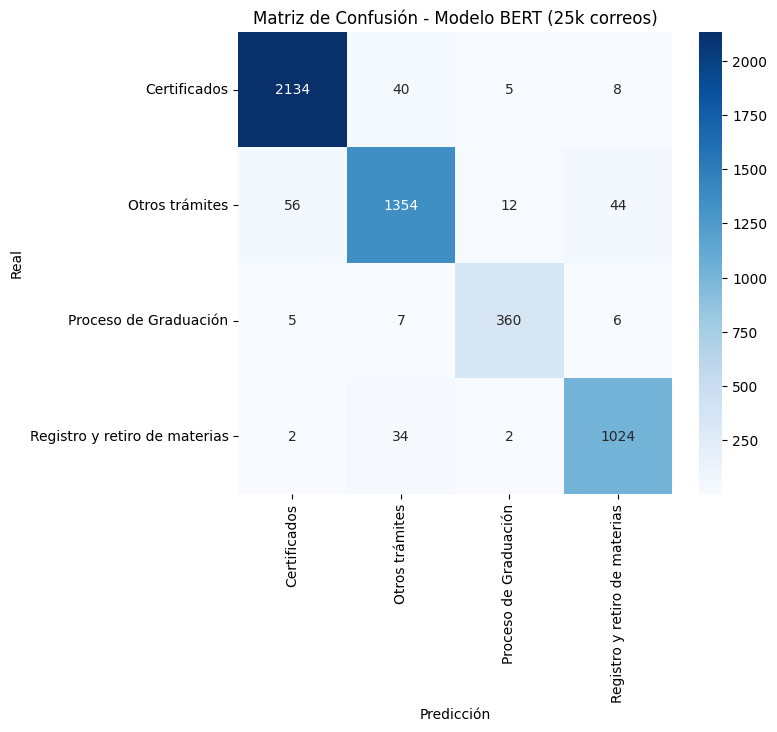

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# predicciones
predictions = trainer.predict(dataset["test"])
preds = np.argmax(predictions.predictions, axis=1)

# matriz
cm = confusion_matrix(predictions.label_ids, preds)

# gráfico
plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Modelo BERT (25k correos)")
plt.show()

Interpretación Métricas:

Se amplió el dataset inicial incorporando aproximadamente 25.000 correos electrónicos adicionales, manteniendo el mismo pipeline de procesamiento y la configuración óptima del modelo.

Los resultados muestran una mejora significativa en el desempeño del modelo, alcanzando un F1-score de 0.96, en comparación con el 0.92 obtenido con el dataset reducido.

Se observa una mejora notable en la clasificación de categorías previamente más complejas, como “Otros trámites”, lo que evidencia el impacto positivo del aumento en el volumen de datos.

Estos resultados confirman que el incremento en la cantidad de datos permite al modelo capturar mejor la variabilidad semántica, mejorando su capacidad de generalización.

El rendimiento del modelo mejora significativamente al aumentar el volumen de datos, lo que demuestra que BERT se beneficia de datasets más grandes para capturar mejor el contexto del lenguaje

Interpretación Matriz de Confusión:

La matriz de confusión evidencia un alto desempeño del modelo, con una clara concentración de predicciones correctas en la diagonal principal.

Se observa que las categorías “Certificados” y “Registro y retiro de materias” presentan un alto nivel de precisión, lo que indica una adecuada diferenciación por parte del modelo.

Por otro lado, la categoría “Otros trámites” muestra mayores niveles de confusión con otras clases, particularmente con “Certificados” y “Registro y retiro de materias”, lo cual puede atribuirse a su naturaleza más general y ambigua.

En general, el modelo demuestra una excelente capacidad de clasificación, con errores concentrados en categorías semánticamente similares.

Aquí vemos que el modelo acierta la gran mayoría de los casos (la diagonal). Los pocos errores se dan en categorías similares, lo cual es esperado en lenguaje natural.